# Airspace Conflict Detection

**Purpose:** This notebook demonstrates how to check flight lines against airspace boundaries to detect conflicts before submitting a flight plan. Airspace conflict detection is a critical safety and regulatory step in mission planning -- flight lines that penetrate restricted, prohibited, or controlled airspace require coordination with air traffic control or rerouting to avoid violations.

**Metadata:**
- **Audience:** Intermediate
- **Runtime:** ~1-2 minutes (includes network requests to FAA servers)
- **Requires internet:** Yes (FAA ArcGIS portal, FAA GeoServer; optional OpenAIP)
- **Credentials required:** None for US airspace; OpenAIP API key for international airspace
- **Optional dependencies:** `cartopy`, `folium`
- **Uses example data:** No (fetches live airspace data from FAA)

**What You Will Learn:**
- How to fetch US airspace data from FAA sources (SUA, SFRA, TFRs, Class B/C/D/E) without an API key
- How to create flight lines and check them for airspace conflicts (horizontal intersection + vertical overlap)
- How to interpret conflict severity levels (HARD, ADVISORY, INFO, NEAR_MISS)
- How to visualize conflicts on maps, vertical profiles, and conflict matrices
- How to filter airspace by active schedule (time-of-day, day-of-week)
- How to fetch international airspace via OpenAIP and oceanic tracks via FlightPlanDB

### Airspace Classes and Why They Matter

Airspace is divided into classes that determine the rules for entry:

| Class | Description | Implication for Flight Planning |
|-------|-------------|-------------------------------|
| **Prohibited / Restricted** | No entry without authorization (e.g., military ranges, nuclear facilities) | Must reroute or obtain prior approval -- these are HARD conflicts |
| **SFRA** | Special Flight Rules Areas (e.g., DC area) | Strict procedures required -- treated as HARD conflicts |
| **Class B/C/D** | Controlled airspace around major/regional airports | Requires ATC clearance -- treated as ADVISORY conflicts |
| **Class E** | General controlled airspace | Informational -- IFR aircraft have ATC services |
| **MOA / Warning / Alert** | Military Operations Areas, Warning Areas | May be active or inactive depending on schedule |
| **TFR** | Temporary Flight Restrictions (e.g., presidential travel, space launches) | Time-limited but strictly enforced |

HyPlan's `airspace` module provides data access, conflict detection, and visualization:

**Data sources:**
1. **`NASRAirspaceSource`** -- US SUA, SFRA, and Class B/C/D/E from the FAA ArcGIS portal (no key)
2. **`FAATFRClient`** -- active TFRs from FAA GeoServer (no key)
3. **`OpenAIPClient`** -- global/international airspace (API key required)
4. **`FlightPlanDBClient`** -- NAT/PACOT oceanic track fetching (no key)

**Analysis:**

5. **`check_airspace_conflicts()`** -- conflict detection with entry/exit point extraction
6. **`check_airspace_proximity()`** -- near-miss proximity warnings with configurable buffer
7. **`fetch_and_check()`** -- one-call convenience (auto-selects FAA for US, OpenAIP for international)
8. **`filter_by_schedule()`** -- filters MOA/restricted areas by active schedule
9. **`convert_agl_floors()`** -- converts SFC-referenced floors to MSL using DEM terrain data
10. **`classify_severity()`** -- HARD / ADVISORY / INFO / NEAR_MISS classification
11. **`summarize_airspaces()`** -- formatted text table for display

**Visualization:**

12. **`plot_airspace_map()`** -- cartopy map with conflicts, entry/exit markers, near-miss halos
13. **`plot_vertical_profile()`** -- altitude cross-section with airspace bands and terrain
14. **`plot_conflict_matrix()`** -- flight line vs. airspace conflict grid
15. **`plot_oceanic_tracks()`** -- NAT/PACOT track map
16. **`map_airspace()`** -- interactive Folium map with hover tooltips and layer toggles

In [1]:
import os
import copy
from datetime import datetime, timezone

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
from dotenv import load_dotenv

from hyplan.airspace import (
    Airspace, AirspaceConflict, OpenAIPClient,
    check_airspace_conflicts, check_airspace_proximity,
    fetch_and_check, clear_airspace_cache,
    classify_severity, FAATFRClient, NASRAirspaceSource,
    convert_agl_floors, filter_by_schedule, summarize_airspaces,
    OceanicTrack, FlightPlanDBClient,
)
from hyplan.plotting import (
    plot_airspace_map, plot_conflict_matrix, plot_vertical_profile,
    plot_oceanic_tracks, map_airspace,
    _AIRSPACE_COLORS, _plot_airspace_polygon,
)
from hyplan.flight_line import FlightLine
from hyplan.units import ureg

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), ".env"))
load_dotenv()

True

## 1. Fetch US Airspace from FAA (No API Key)

`NASRAirspaceSource` queries the FAA ArcGIS portal for Special Use
Airspace (Restricted, Prohibited, MOA, Warning, Alert areas).
**No API key required.** Cached for 28 days.

In [2]:
nasr = NASRAirspaceSource()

# Vandenberg / Santa Barbara area
airspaces = nasr.fetch_airspaces(bounds=(-121.0, 34.2, -119.5, 35.0))
print(summarize_airspaces(airspaces, header="Vandenberg SUA"))

Vandenberg SUA: 6

  R-2534B                                   RESTRICTED         500 –    UNLTD ft  [SFC]
  R-2517                                    RESTRICTED           0 –    UNLTD ft  [SFC]
  W-532S                                    WARNING_AREA         0 –    UNLTD ft  [SFC]
  W-537                                     WARNING_AREA         0 –    UNLTD ft  [SFC]
  R-2534A                                   RESTRICTED         500 –    UNLTD ft  [SFC]
  R-2516                                    RESTRICTED           0 –    UNLTD ft  [SFC]


The query returned 6 airspace zones around Vandenberg Air Force Base, all with unlimited ceilings. This area is heavily restricted due to military missile testing and space launch operations. The mix of RESTRICTED and WARNING_AREA types means some zones are always active (Restricted) while Warning Areas may have scheduled activation times.

## 2. Create Flight Lines

Four flight lines around the Vandenberg area at different altitudes.

In [3]:
# Line A — through Vandenberg restricted zone at 2,500 ft
line_a = FlightLine.start_length_azimuth(
    lat1=34.75, lon1=-120.8, length=ureg.Quantity(50, "km"), az=60,
    altitude_msl=ureg.Quantity(2500, "foot"), site_name="Line A (low, Vandenberg)",
)

# Line B — through the danger zone at 10,000 ft
line_b = FlightLine.start_length_azimuth(
    lat1=34.55, lon1=-120.6, length=ureg.Quantity(30, "km"), az=45,
    altitude_msl=ureg.Quantity(10000, "foot"), site_name="Line B (danger zone)",
)

# Line C — east of Santa Barbara, clear of all zones
line_c = FlightLine.start_length_azimuth(
    lat1=34.5, lon1=-119.6, length=ureg.Quantity(40, "km"), az=0,
    altitude_msl=ureg.Quantity(8000, "foot"), site_name="Line C (clear)",
)

# Line D — high altitude through R-2534B area
line_d = FlightLine.start_length_azimuth(
    lat1=34.42, lon1=-120.55, length=ureg.Quantity(30, "km"), az=90,
    altitude_msl=ureg.Quantity(20000, "foot"), site_name="Line D (high, R-2534B)",
)

flight_lines = [line_a, line_b, line_c, line_d]
for fl in flight_lines:
    print(f"  {fl.site_name:35s}  alt = {fl.altitude_msl.to('foot'):,.0f}")

  Line A (low, Vandenberg)             alt = 2,500 foot
  Line B (danger zone)                 alt = 10,000 foot
  Line C (clear)                       alt = 8,000 foot
  Line D (high, R-2534B)               alt = 20,000 foot


## 3. Run Conflict Detection

`check_airspace_conflicts()` tests each flight line against each airspace
for horizontal intersection plus vertical altitude overlap. Entry and
exit points are automatically extracted.

In [4]:
conflicts = check_airspace_conflicts(flight_lines, airspaces)

print(f"Found {len(conflicts)} conflict(s):\n")
for c in conflicts:
    fl = flight_lines[c.flight_line_index]
    print(f"  {fl.site_name}  \u2194  {c.airspace.name} [{c.severity}]")
    if c.entry_point:
        print(f"    Entry: ({c.entry_point[1]:.4f}\u00b0N, {c.entry_point[0]:.4f}\u00b0E)")
    if c.exit_point:
        print(f"    Exit:  ({c.exit_point[1]:.4f}\u00b0N, {c.exit_point[0]:.4f}\u00b0E)")

Found 9 conflict(s):

  Line A (low, Vandenberg)  ↔  W-532S [INFO]
    Entry: (34.7500°N, -120.8000°E)
    Exit:  (34.8055°N, -120.6826°E)
  Line A (low, Vandenberg)  ↔  R-2516 [HARD]
    Entry: (34.8055°N, -120.6826°E)
    Exit:  (34.8712°N, -120.5439°E)
  Line B (danger zone)  ↔  R-2534B [HARD]
    Entry: (34.6078°N, -120.5299°E)
    Exit:  (34.6257°N, -120.5082°E)
  Line B (danger zone)  ↔  R-2534A [HARD]
    Entry: (34.6257°N, -120.5082°E)
    Exit:  (34.6275°N, -120.5060°E)
  Line B (danger zone)  ↔  R-2517 [HARD]
    Entry: (34.5500°N, -120.6000°E)
    Exit:  (34.6078°N, -120.5299°E)
  Line D (high, R-2534B)  ↔  W-532S [INFO]
    Entry: (34.4200°N, -120.5500°E)
    Exit:  (34.4200°N, -120.5235°E)
  Line D (high, R-2534B)  ↔  R-2534B [HARD]
    Entry: (34.4199°N, -120.4527°E)
    Exit:  (34.4197°N, -120.3280°E)
  Line D (high, R-2534B)  ↔  R-2534A [HARD]
    Entry: (34.4197°N, -120.3280°E)
    Exit:  (34.4196°N, -120.2595°E)
  Line D (high, R-2534B)  ↔  R-2517 [HARD]
    Entry: (3

The conflict detector found 9 conflicts across 3 of the 4 flight lines. Line C (east of Santa Barbara) is clear of all airspace -- it was deliberately placed outside restricted zones. Lines A, B, and D all penetrate restricted or warning areas at various altitudes. The entry and exit points pinpoint exactly where each flight line crosses an airspace boundary, which is essential for determining how to shorten or reroute lines to avoid conflicts.

## 4. Visualize Conflicts

`plot_airspace_map()` renders airspaces, flight lines, conflicts,
and entry/exit markers (red/orange diamonds) on a cartopy basemap.

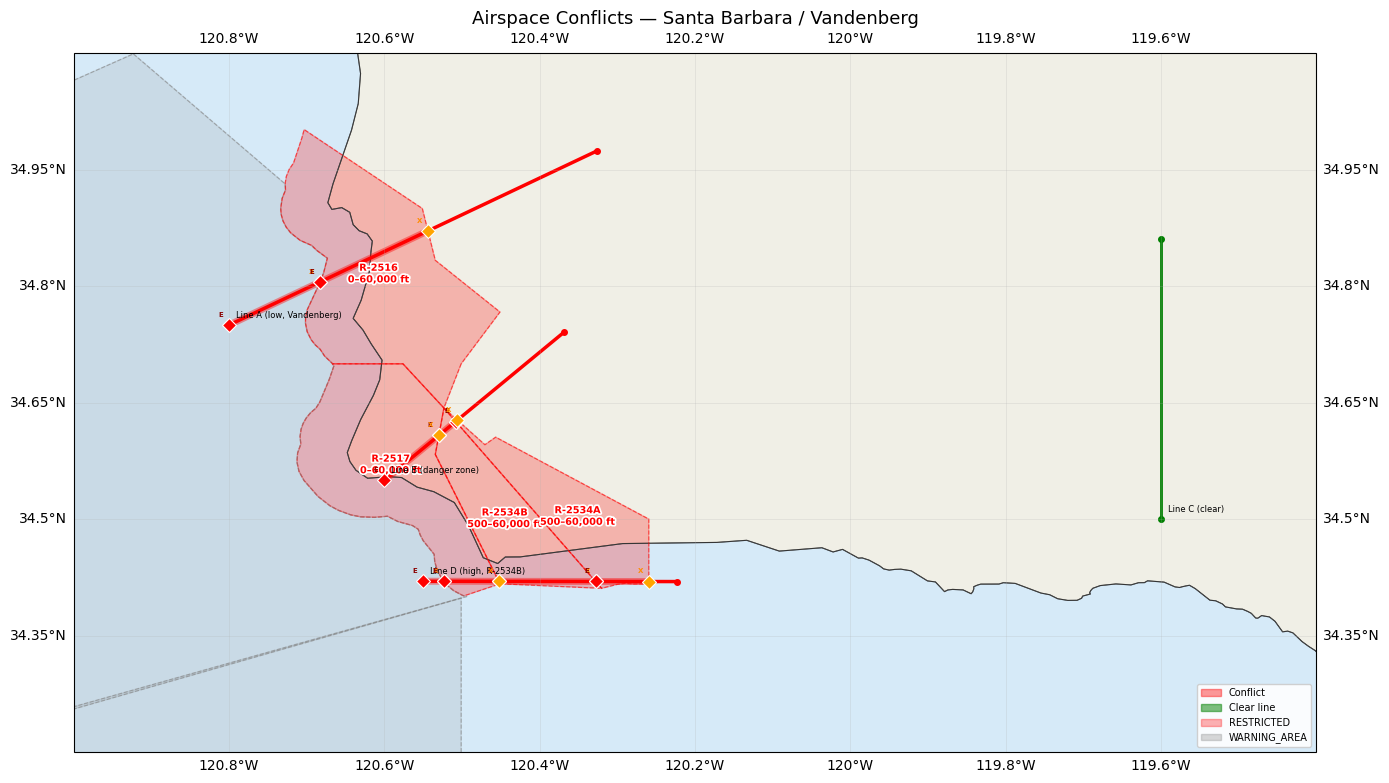

In [5]:
fig, ax = plot_airspace_map(
    airspaces, flight_lines, conflicts,
    title="Airspace Conflicts \u2014 Santa Barbara / Vandenberg",
    extent=[-121.0, -119.4, 34.2, 35.1],
)

The map visualization makes it easy to see which flight lines intersect airspace polygons. Red and orange diamond markers show entry and exit points. Line C (green, to the east) is visually clear of all zones, confirming the numerical analysis. This type of map is useful for briefing pilots and mission planners on where conflicts exist and where safe corridors are available.

## 5. Conflict Matrix

RED = full conflict, ORANGE = horizontal-only (altitude clear), GRAY = no intersection.

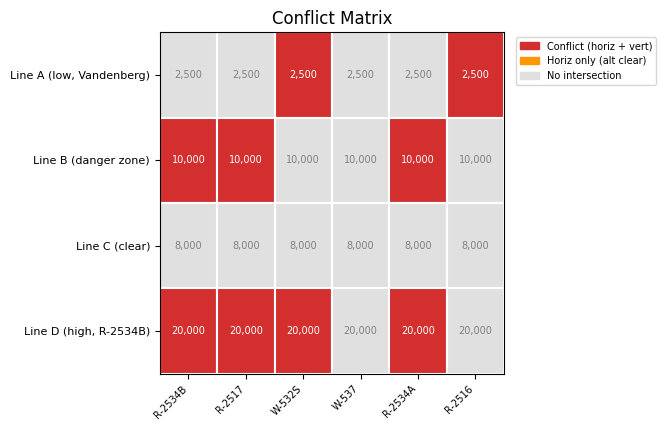

In [6]:
fig, ax = plot_conflict_matrix(flight_lines, airspaces)

The conflict matrix provides a compact summary of all flight line vs. airspace interactions. Red cells indicate full 3D conflicts (horizontal overlap AND altitude overlap). Orange cells would indicate horizontal-only overlap where the flight altitude is above or below the airspace -- useful for identifying lines that are "close calls" vertically. Gray cells mean no geometric intersection at all.

## 6. Near-Miss Proximity Warnings

`check_airspace_proximity()` detects flight lines that pass *near* but
not *through* airspace. Gold dashed lines and buffer halos mark near-misses.

Near-miss warnings (2 km buffer): 0



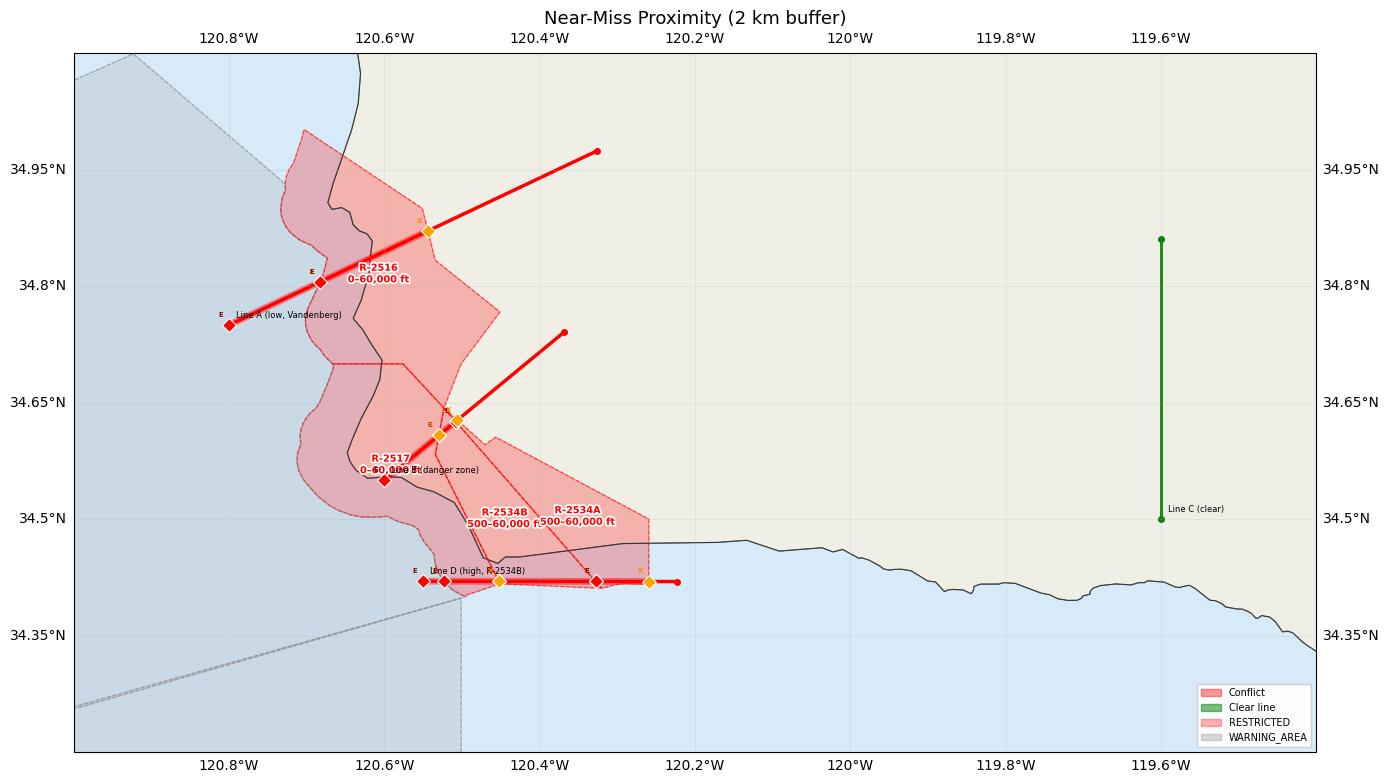

In [7]:
near_misses = check_airspace_proximity(
    flight_lines, airspaces, buffer_m=2000,
)

print(f"Near-miss warnings (2 km buffer): {len(near_misses)}\n")
for nm in near_misses[:10]:
    fl = flight_lines[nm.flight_line_index]
    print(f"  {fl.site_name} \u2194 {nm.airspace.name[:40]}")
    print(f"    Distance: {nm.distance_to_boundary_m:,.0f} m")

fig, ax = plot_airspace_map(
    airspaces, flight_lines, conflicts,
    near_misses=near_misses, buffer_m=2000,
    title="Near-Miss Proximity (2 km buffer)",
    extent=[-121.0, -119.4, 34.2, 35.1],
)

Near-miss warnings identify flight lines that pass close to but not through airspace boundaries. This is important because small navigation errors, wind drift, or last-minute route adjustments could push a flight line into restricted airspace. The 2 km buffer used here is a conservative margin -- operational buffers should be adjusted based on navigation accuracy and the severity of the adjacent airspace.

## 7. Conflict Severity Classification

| Severity | Airspace Types |
|----------|---------------|
| **HARD** | Prohibited, Restricted, SFRA |
| **ADVISORY** | Danger, CTR, TMA, RMZ, ATZ, MATZ, TFR, Class B/C/D |
| **INFO** | FIR, UIR, Class E |
| **NEAR_MISS** | Proximity warnings from `check_airspace_proximity()` |

In [8]:
for c in conflicts:
    fl = flight_lines[c.flight_line_index]
    print(f"  [{c.severity:8s}]  {fl.site_name:30s}  \u2194  {c.airspace.name[:30]}")

  [INFO    ]  Line A (low, Vandenberg)        ↔  W-532S
  [HARD    ]  Line A (low, Vandenberg)        ↔  R-2516
  [HARD    ]  Line B (danger zone)            ↔  R-2534B
  [HARD    ]  Line B (danger zone)            ↔  R-2534A
  [HARD    ]  Line B (danger zone)            ↔  R-2517
  [INFO    ]  Line D (high, R-2534B)          ↔  W-532S
  [HARD    ]  Line D (high, R-2534B)          ↔  R-2534B
  [HARD    ]  Line D (high, R-2534B)          ↔  R-2534A
  [HARD    ]  Line D (high, R-2534B)          ↔  R-2517


## 8. One-Call Convenience: `fetch_and_check()`

Auto-selects FAA sources for US queries. Unlike the manual NASR fetch
above (SUA only), this combines **SUA + SFRA + Class B/C/D + TFRs**
in a single call, so it may return additional conflicts from class
airspace and TFRs.

In [9]:
quick_conflicts = fetch_and_check(flight_lines, buffer_m=40000)
print(f"Found {len(quick_conflicts)} conflict(s) via fetch_and_check():\n")
for c in quick_conflicts:
    fl = flight_lines[c.flight_line_index]
    print(f"  {fl.site_name}  \u2194  {c.airspace.name[:40]} ({c.airspace.source})")

# Filter to RESTRICTED only
restricted_only = fetch_and_check(
    flight_lines, buffer_m=40000, type_filter="RESTRICTED",
)
print(f"\nRestricted-only conflicts: {len(restricted_only)}")

Found 10 conflict(s) via fetch_and_check():

  Line A (low, Vandenberg)  ↔  W-532S (faa_nasr)
  Line A (low, Vandenberg)  ↔  R-2516 (faa_nasr)
  Line A (low, Vandenberg)  ↔  SANTA MARIA CLASS D (faa_nasr)
  Line B (danger zone)  ↔  R-2517 (faa_nasr)
  Line B (danger zone)  ↔  R-2534B (faa_nasr)
  Line B (danger zone)  ↔  R-2534A (faa_nasr)
  Line D (high, R-2534B)  ↔  W-532S (faa_nasr)
  Line D (high, R-2534B)  ↔  R-2517 (faa_nasr)
  Line D (high, R-2534B)  ↔  R-2534B (faa_nasr)
  Line D (high, R-2534B)  ↔  R-2534A (faa_nasr)

Restricted-only conflicts: 7


## 9. Special Flight Rules Areas (SFRAs)

`NASRAirspaceSource.fetch_sfras()` returns DC SFRA, Grand Canyon,
NYC Hudson River, and other special airspace. Severity = **HARD**.

SFRAs in DC area: 2

  WASHINGTON, DC METROPOLITAN AREA SPECIAL FLIGHT RULES AREA
    0 – 18,000 ft  [HARD]
  WASHINGTON, DC METROPOLITAN AREA SPECIAL FLIGHT RULES AREA
    0 – 18,000 ft  [HARD]


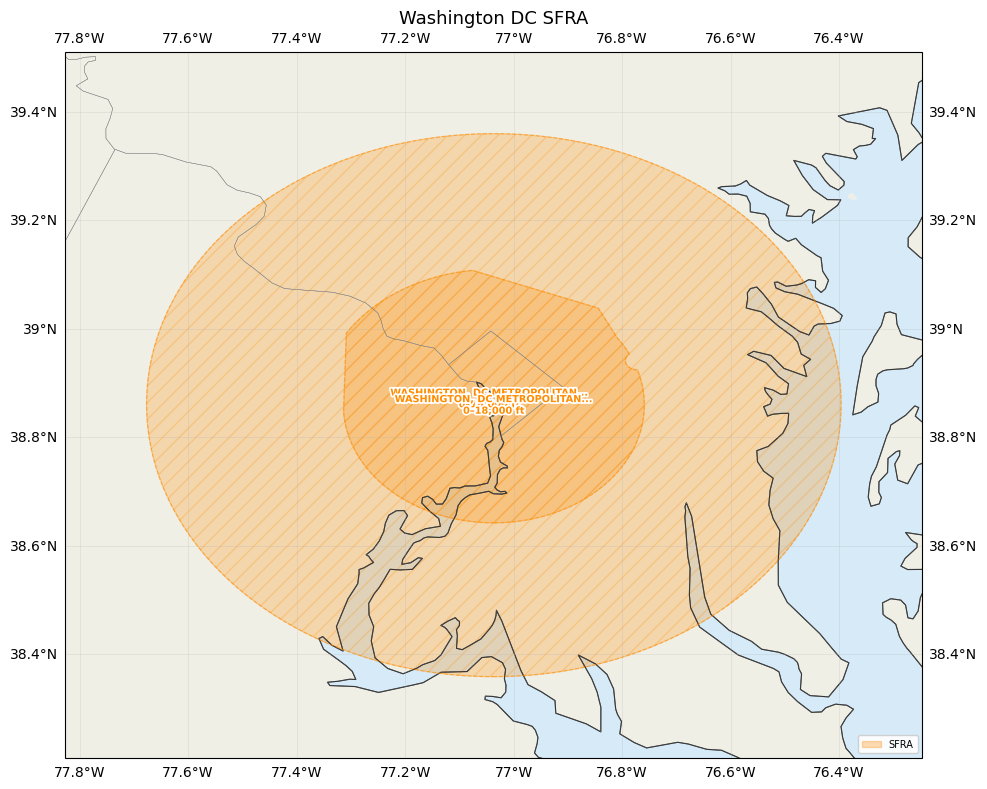

In [10]:
# Fetch and plot the DC SFRA
sfras = nasr.fetch_sfras(bounds=(-78.0, 38.0, -76.0, 39.5))
print(f"SFRAs in DC area: {len(sfras)}\n")
for s in sfras:
    sev = classify_severity(s.airspace_type)
    print(f"  {s.name[:60]}")
    print(f"    {s.floor_ft:,.0f} \u2013 {s.ceiling_ft:,.0f} ft  [{sev}]")

fig, ax = plot_airspace_map(
    sfras, title="Washington DC SFRA",
    figsize=(10, 8),
)

## 10. FAA Temporary Flight Restrictions (TFRs)

`FAATFRClient` fetches active TFRs from the FAA GeoServer WFS endpoint.
**No API key required.** TFRs with parseable dates support `effective_only`
filtering. Here we test around Cape Canaveral.

TFRs near Cape Canaveral: 0


SUA restricted areas: 44
Total airspace objects: 44

Conflicts: 8
  Canaveral Low (3k ft)          ↔ W-497A  [INFO]
    Entry: (28.617°N, -80.531°W)
  Canaveral Low (3k ft)          ↔ R-2932  [HARD]
    Entry: (28.583°N, -80.668°W)
  Canaveral Low (3k ft)          ↔ R-2934  [HARD]
    Entry: (28.563°N, -80.750°W)
  Canaveral High (15k ft)        ↔ R-2934  [HARD]
    Entry: (28.446°N, -80.705°W)
  Canaveral High (15k ft)        ↔ W-497A  [INFO]
    Entry: (28.588°N, -80.516°W)
  Canaveral High (15k ft)        ↔ R-2933  [HARD]
    Entry: (28.491°N, -80.645°W)
  Canaveral High (15k ft)        ↔ R-2934  [HARD]
    Entry: (28.469°N, -80.675°W)
  Canaveral High (15k ft)        ↔ R-2935  [HARD]
    Entry: (28.369°N, -80.808°W)

Nationwide: 98 total, 68 currently effective


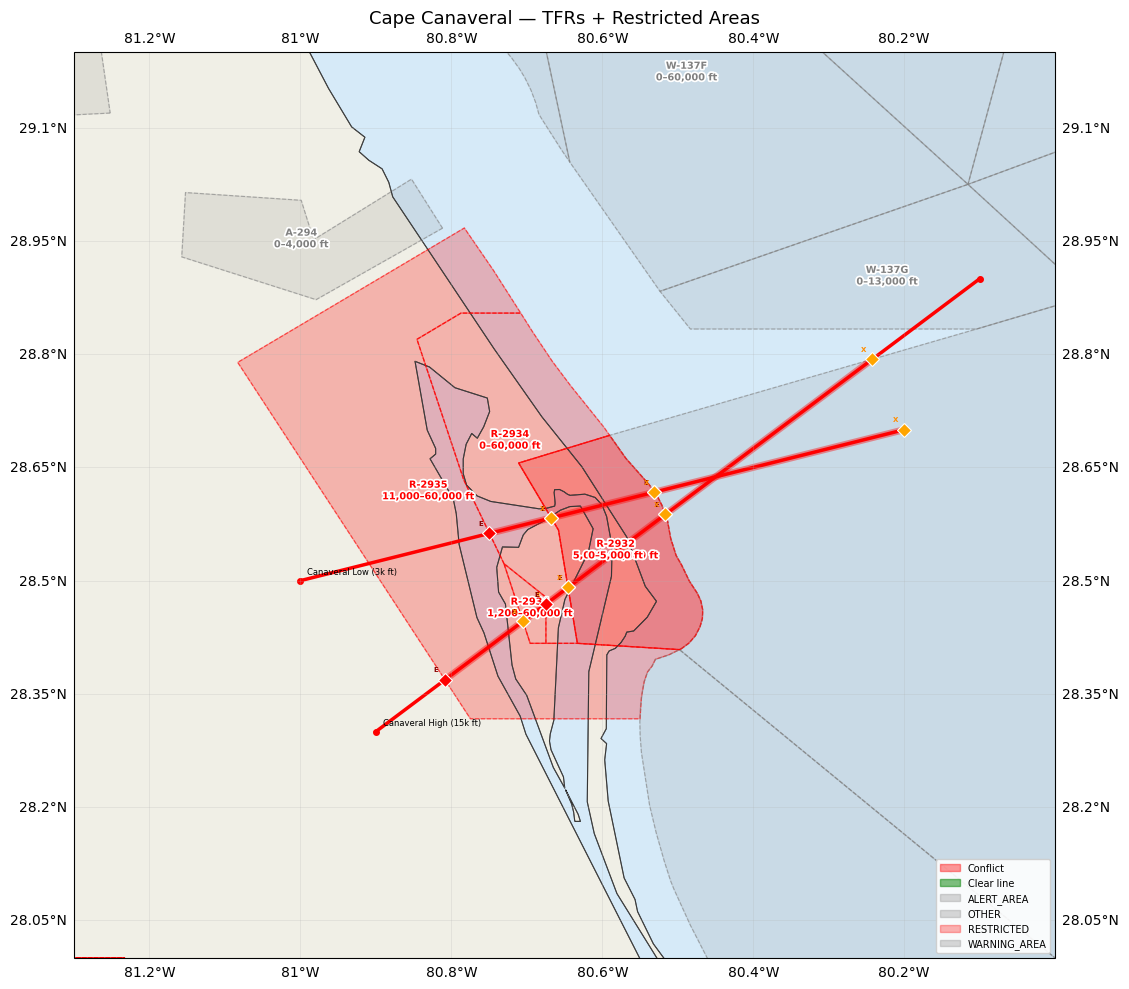

In [11]:
tfr_client = FAATFRClient(cache_ttl_hours=1.0)
canaveral_bounds = (-81.5, 27.5, -79.5, 29.5)

try:
    # Fetch all TFRs (including future-dated space-ops launches)
    tfrs = tfr_client.fetch_tfrs(bounds=canaveral_bounds)
    print(f"TFRs near Cape Canaveral: {len(tfrs)}\n")
    for t in tfrs:
        print(f"  {t.name[:70]}")
        if t.effective_start:
            print(f"    Effective: {t.effective_start}")

    # Also fetch SUA restricted areas (always present)
    sua_cc = nasr.fetch_airspaces(bounds=canaveral_bounds)
    all_airspace = tfrs + sua_cc
    print(f"\nSUA restricted areas: {len(sua_cc)}")
    print(f"Total airspace objects: {len(all_airspace)}")

    # Two flight lines through the Cape Canaveral complex
    fl_low = FlightLine.from_endpoints(
        28.5, -81.0, 28.7, -80.2,
        altitude_msl=3000 * ureg.foot, site_name="Canaveral Low (3k ft)",
    )
    fl_high = FlightLine.from_endpoints(
        28.3, -80.9, 28.9, -80.1,
        altitude_msl=15000 * ureg.foot, site_name="Canaveral High (15k ft)",
    )

    # Check both flight lines against TFRs + SUA
    cc_conflicts = check_airspace_conflicts([fl_low, fl_high], all_airspace)
    print(f"\nConflicts: {len(cc_conflicts)}")
    for c in cc_conflicts:
        fl = [fl_low, fl_high][c.flight_line_index]
        print(f"  {fl.site_name:30s} \u2194 {c.airspace.name[:35]}  [{c.severity}]")
        if c.entry_point:
            print(f"    Entry: ({c.entry_point[1]:.3f}\u00b0N, {c.entry_point[0]:.3f}\u00b0W)")

    # Plot everything
    fig, ax = plot_airspace_map(
        all_airspace, [fl_low, fl_high], cc_conflicts,
        title="Cape Canaveral \u2014 TFRs + Restricted Areas",
        extent=[-81.3, -80.0, 28.0, 29.2],
    )

    # Nationwide TFR count
    all_tfrs = tfr_client.fetch_tfrs()
    all_eff = tfr_client.fetch_tfrs(effective_only=True)
    print(f"\nNationwide: {len(all_tfrs)} total, {len(all_eff)} currently effective")
except Exception as e:
    import traceback; traceback.print_exc()

## 11. Active Schedule Filtering

`filter_by_schedule()` parses the NASR `TIMESOFUSE` field and removes
inactive airspaces. Here we compare weekday midday vs. weekend night
around Cape Canaveral, which has many intermittent restricted areas.

SUA with schedules: 44 of 44

  R-2901M                    INTERMITTENT, 0600 - 2400, MON - FRI; 0800 - 1800, SAT 
  W-139F                     CONTINUOUS
  R-2933                     INTERMITTENT BY NOTAM NORMALLY 24 HOURS IN ADVANCE
  W-136F                     CONTINUOUS
  R-2901A                    INTERMITTENT, 0600 - 2400, MON - FRI; 0800 - 1800, SAT 
  R-2907A                    INTERMITTENT, 0800 - 2400, DAILY; O/T BY NOTAM 6 HOURS 
  AVON EAST MOA              INTERMITTENT, SUNRISE - SUNSET, MON - FRI; OTHER TIMES 
  R-2935                     INTERMITTENT BY NOTAM NORMALLY 24 HOURS IN ADVANCE

Active Wed 1pm ET: 44/44
Active Sat 3am UTC: 44/44


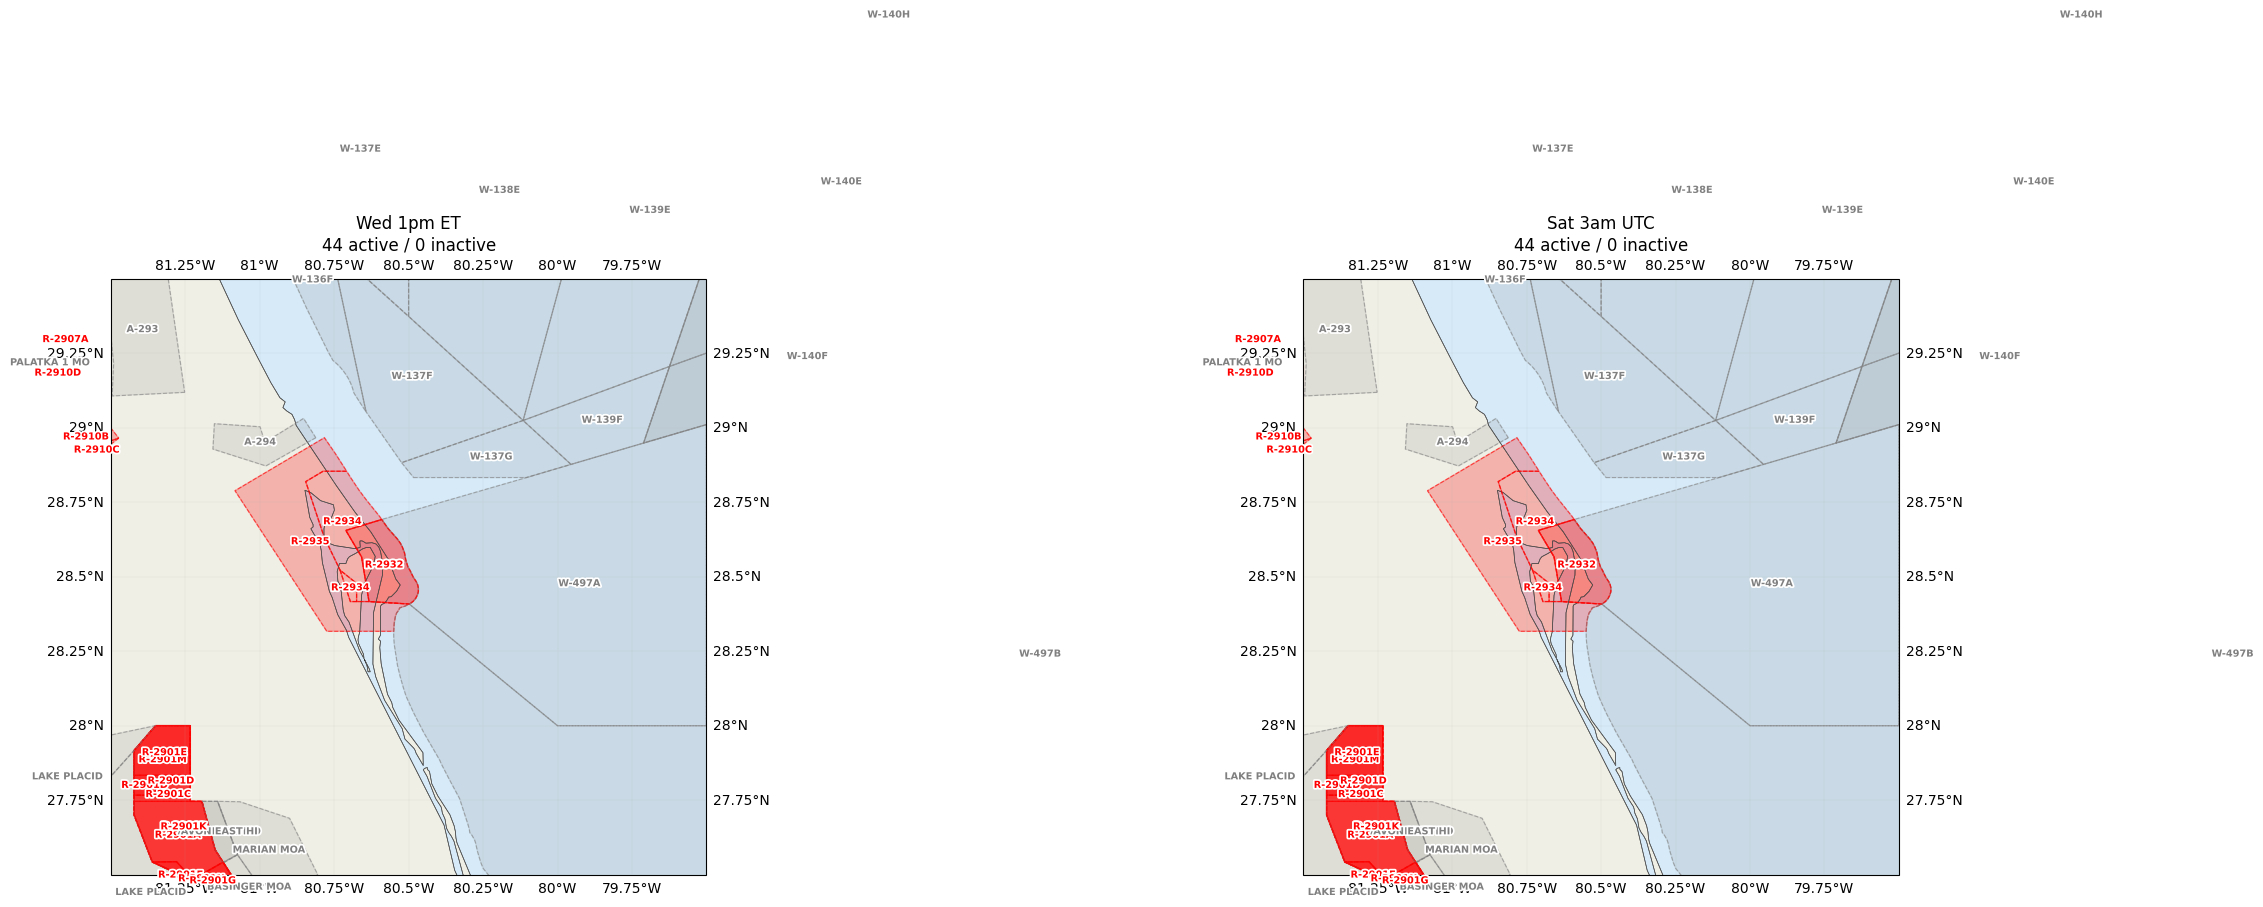

In [12]:
sua_cc = nasr.fetch_airspaces(bounds=canaveral_bounds)
with_schedule = [a for a in sua_cc if a.schedule]
print(f"SUA with schedules: {len(with_schedule)} of {len(sua_cc)}\n")
for a in with_schedule[:8]:
    print(f"  {a.name:25s}  {a.schedule[:55]}")

weekday_midday = datetime(2026, 4, 15, 18, 0, tzinfo=timezone.utc)  # Wed 1pm ET
weekend_night = datetime(2026, 4, 18, 3, 0, tzinfo=timezone.utc)

active_wd = filter_by_schedule(sua_cc, at_datetime=weekday_midday)
active_we = filter_by_schedule(sua_cc, at_datetime=weekend_night)
print(f"\nActive Wed 1pm ET: {len(active_wd)}/{len(sua_cc)}")
print(f"Active Sat 3am UTC: {len(active_we)}/{len(sua_cc)}")

# Side-by-side comparison (large figure)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10),
    subplot_kw={"projection": ccrs.PlateCarree()})

for axi, active, title_label in [
    (ax1, active_wd, "Wed 1pm ET"),
    (ax2, active_we, "Sat 3am UTC"),
]:
    inactive = [a for a in sua_cc if a not in active]
    axi.add_feature(cfeature.LAND, facecolor="#f0efe6")
    axi.add_feature(cfeature.OCEAN, facecolor="#d6eaf8")
    axi.add_feature(cfeature.COASTLINE, linewidth=0.5)
    axi.add_feature(cfeature.STATES, linewidth=0.3, edgecolor="gray")
    for a in inactive:
        _plot_airspace_polygon(axi, a, "lightgray", 0.15, ccrs.PlateCarree(), hatch="//")
        cx, cy = a.geometry.centroid.coords[0]
        axi.text(cx, cy, a.name[:12], ha="center", va="center",
                 fontsize=6, color="gray", style="italic",
                 transform=ccrs.PlateCarree(),
                 path_effects=[pe.withStroke(linewidth=2, foreground="white")])
    for a in active:
        color, alpha = _AIRSPACE_COLORS.get(a.airspace_class, ("gray", 0.15))
        _plot_airspace_polygon(axi, a, color, alpha, ccrs.PlateCarree())
        cx, cy = a.geometry.centroid.coords[0]
        axi.text(cx, cy, a.name[:12], ha="center", va="center",
                 fontsize=7, color=color, weight="bold",
                 transform=ccrs.PlateCarree(),
                 path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
    axi.set_extent([-81.5, -79.5, 27.5, 29.5], crs=ccrs.PlateCarree())
    axi.set_title(f"{title_label}\n{len(active)} active / {len(inactive)} inactive", fontsize=12)
    axi.gridlines(draw_labels=True, linewidth=0.3, alpha=0.3)
plt.tight_layout()
plt.show()

The side-by-side comparison reveals how airspace availability changes with time. Fewer restricted areas are active on a Saturday night compared to a Wednesday afternoon. This has practical implications: scheduling flights during off-peak times (weekends, nights) may open corridors that are blocked during normal business hours. However, always verify schedules through official NOTAMs, as military exercises and other events can activate airspace outside normal schedules.

## 12. FAA Class B/C/D/E Airspace

`NASRAirspaceSource.fetch_class_airspace()` returns controlled airspace
around airports. **No API key required.** Default: B, C, D (not E).
Class B/C/D = ADVISORY severity; E = INFO.

Class airspace near LA: 45

  SANTA ANA CLASS C                         C                    0 –    4,400 ft  [MSL]
  RIVERSIDE MARCH FIELD CLASS C             C                2,900 –    5,500 ft  [MSL]
  LOS ANGELES CLASS B                       B                2,500 –   10,000 ft  [MSL]
  VAN NUYS CLASS D                          D                    0 –    3,000 ft  [MSL]
  SANTA ANA CLASS C                         C                3,500 –    4,400 ft  [MSL]
  LOS ANGELES CLASS B                       B                8,000 –   10,000 ft  [MSL]
  HAWTHORNE CLASS D                         D                    0 –    2,500 ft  [MSL]
  RIVERSIDE MARCH FIELD CLASS C             C                    0 –    5,500 ft  [MSL]
  LOS ANGELES CLASS B                       B                5,000 –   10,000 ft  [MSL]
  SANTA ANA CLASS C                         C                2,500 –    5,400 ft  [MSL]
  RIVERSIDE MARCH FIELD CLASS D             D                    0 –    4,000 ft  [MSL]
  BU

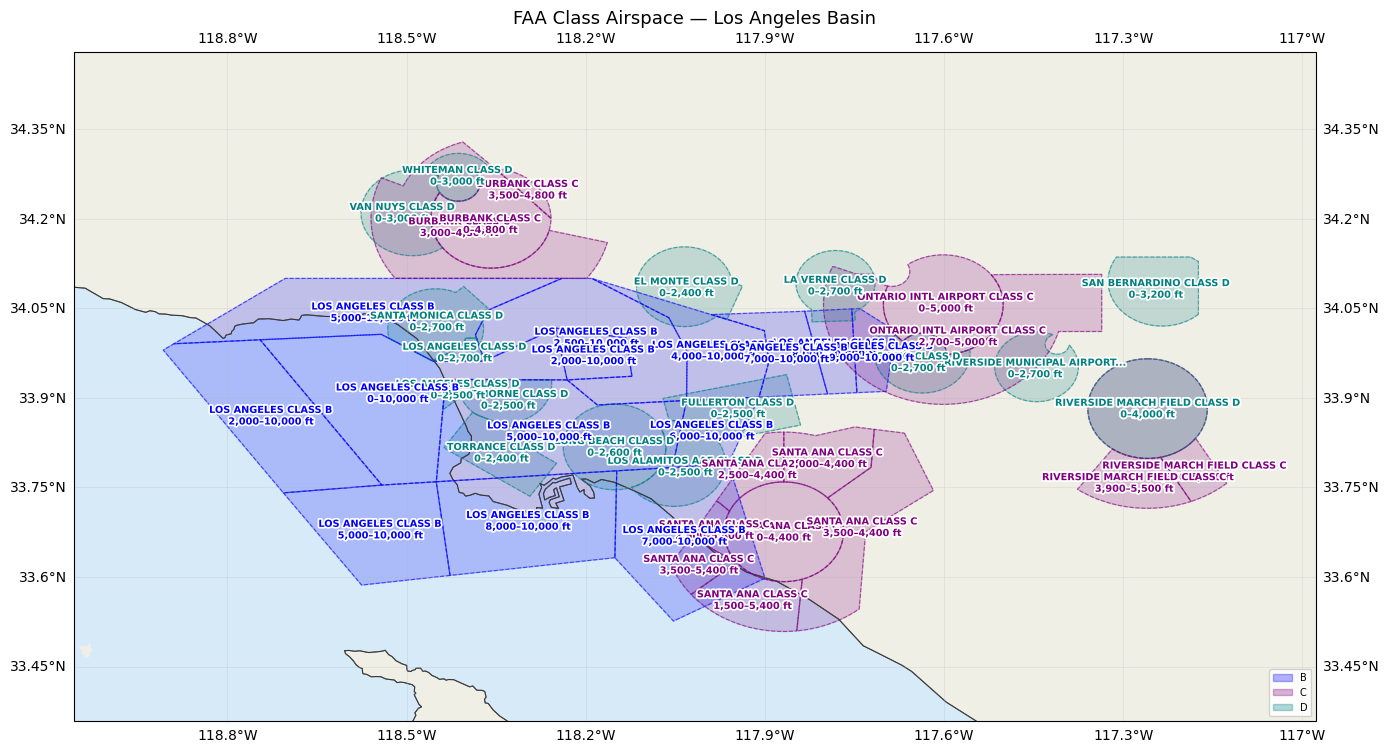

In [13]:
# Class airspace around the LA Basin
la_bounds = (-118.8, 33.5, -117.2, 34.3)
cls = nasr.fetch_class_airspace(bounds=la_bounds)
print(summarize_airspaces(cls, header="Class airspace near LA"))

fig, ax = plot_airspace_map(
    cls, title="FAA Class Airspace \u2014 Los Angeles Basin",
)

## 13. Vertical Profile Through LA Airspace

`plot_vertical_profile()` shows an altitude cross-section along a flight
line with airspace floor/ceiling bands colored by severity. Here we fly
a low-altitude corridor through the complex layered Class B/C/D airspace
around Los Angeles.

Class airspace sectors: 45



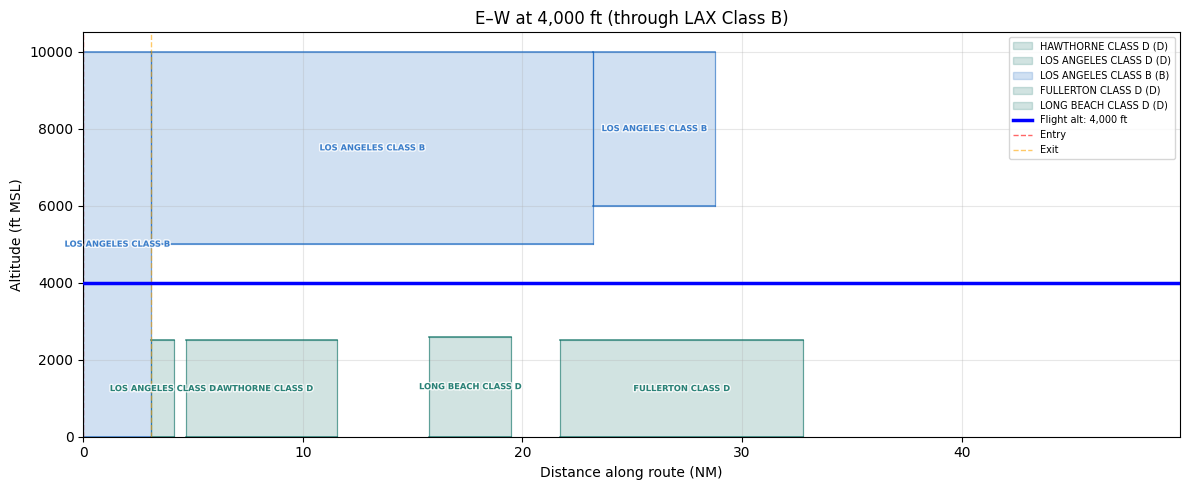

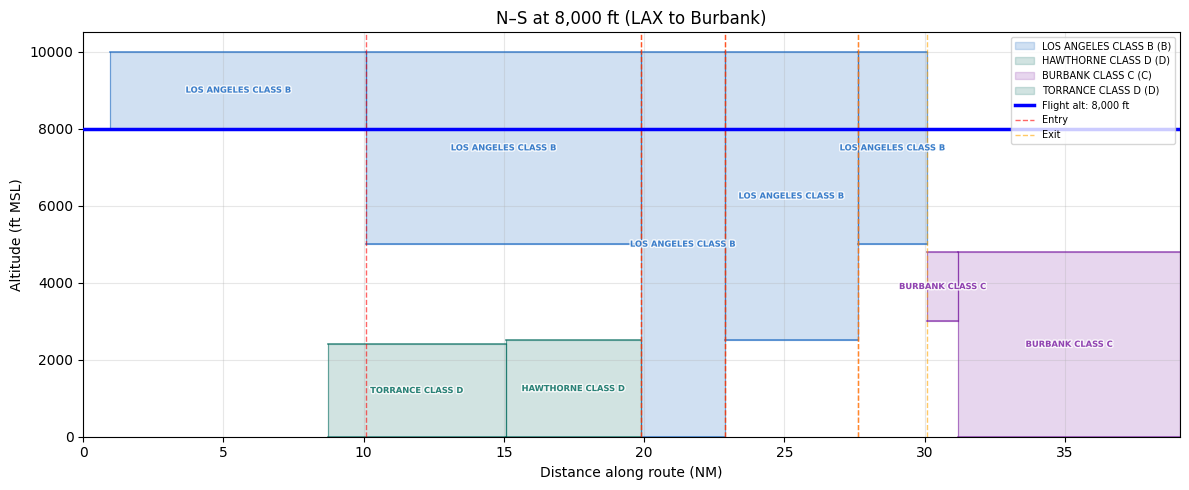

In [14]:
# Fetch class airspace around LA
la_bounds = (-118.8, 33.5, -117.2, 34.3)
la_airspace = nasr.fetch_class_airspace(bounds=la_bounds)
print(f"Class airspace sectors: {len(la_airspace)}\n")

# Flight line 1: Low E-W corridor through LAX Class B
la_fl_low = FlightLine.from_endpoints(
    33.9, -118.5, 33.85, -117.5,
    altitude_msl=4000 * ureg.foot, site_name="LA Low Corridor (4,000 ft)",
)

# Flight line 2: Higher N-S through LAX and Burbank
la_fl_high = FlightLine.from_endpoints(
    33.6, -118.3, 34.25, -118.35,
    altitude_msl=8000 * ureg.foot, site_name="LA N-S Transit (8,000 ft)",
)

# Vertical profile 1: E-W at 4,000 ft
fig, ax = plot_vertical_profile(la_fl_low, la_airspace,
    title="E\u2013W at 4,000 ft (through LAX Class B)")
plt.show()

# Vertical profile 2: N-S at 8,000 ft
fig, ax = plot_vertical_profile(la_fl_high, la_airspace,
    title="N\u2013S at 8,000 ft (LAX to Burbank)")
plt.show()

The vertical profile plots are especially valuable for understanding layered airspace structures like the LA Basin. The E-W profile at 4,000 ft shows the aircraft flying through multiple Class B shelf layers. The N-S profile at 8,000 ft shows a different set of conflicts. By examining these cross-sections, mission planners can identify altitude windows where flight is possible without entering controlled airspace -- or determine which ATC clearances will be needed.

## 14. AGL-to-MSL Floor Conversion

Some airspace floors are surface-referenced (AGL/SFC). `convert_agl_floors()`
uses a DEM to convert them to MSL. Here we use the Edwards AFB / Mojave area
where MOAs have SFC-referenced floors over mountainous terrain.

Edwards SUA: 17, SFC floors: 14

  ISABELLA MOA                         floor= 1,500 ft AGL
  ISABELLA MOA                         floor= 1,500 ft AGL
  PANAMINT MOA                         floor=   200 ft AGL
  BAKERSFIELD MOA                      floor= 2,000 ft AGL
  R-2515                               floor=     0 ft AGL
  ISABELLA MOA                         floor= 1,500 ft AGL
  BUCKHORN MOA                         floor=   200 ft AGL
  R-2524                               floor=     0 ft AGL


71 query point(s) fall outside the DEM extent. Edge pixel elevations will be used for these points.
65 query point(s) fall outside the DEM extent. Edge pixel elevations will be used for these points.



AGL → MSL conversion results:
  ISABELLA MOA                          1,500 AGL + 5,437 terrain =   6,937 MSL
  ISABELLA MOA                          1,500 AGL + 5,437 terrain =   6,937 MSL
  PANAMINT MOA                            200 AGL + 7,144 terrain =   7,344 MSL
  BAKERSFIELD MOA                       2,000 AGL + 6,499 terrain =   8,499 MSL
  ISABELLA MOA                          1,500 AGL + 5,437 terrain =   6,937 MSL
  BUCKHORN MOA                            200 AGL + 3,095 terrain =   3,295 MSL
  ISABELLA MOA                          1,500 AGL + 5,437 terrain =   6,937 MSL
  BARSTOW MOA                             200 AGL + 3,600 terrain =   3,800 MSL


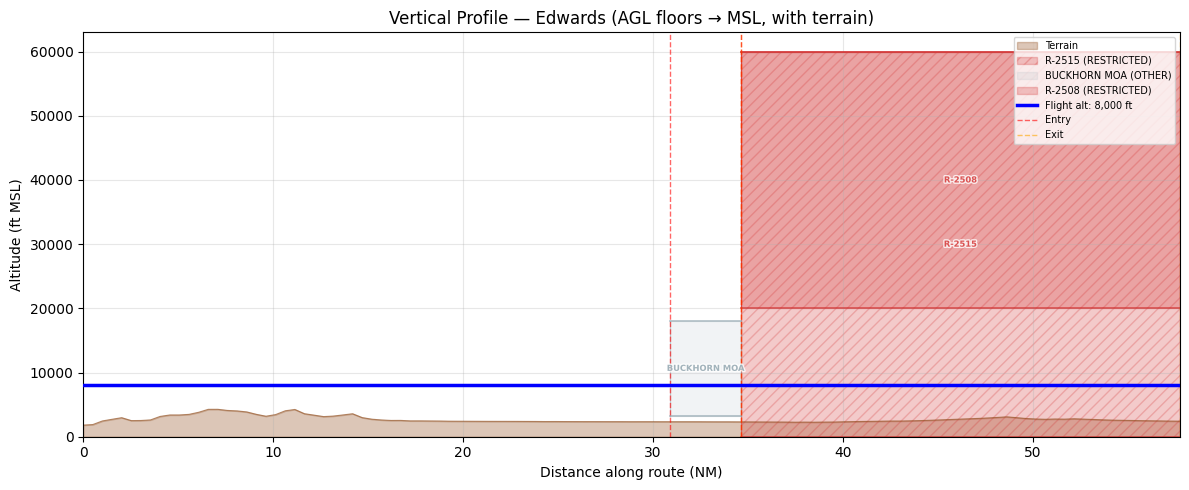

In [15]:
# Edwards / Mojave area - SUA with SFC-referenced floors
edwards_bounds = (-119.0, 34.0, -117.0, 35.5)
sua_edwards = nasr.fetch_airspaces(bounds=edwards_bounds)
sfc_floors = [a for a in sua_edwards if a.floor_reference == "SFC"]
print(f"Edwards SUA: {len(sua_edwards)}, SFC floors: {len(sfc_floors)}\n")

for a in sfc_floors[:8]:
    print(f"  {a.name:35s}  floor={a.floor_ft:>6,.0f} ft AGL")

# Auto-download DEM and convert AGL to MSL
from hyplan.terrain import generate_demfile
dem_file = generate_demfile(
    np.array([edwards_bounds[1], edwards_bounds[3]]),
    np.array([edwards_bounds[0], edwards_bounds[2]]),
)

sua_converted = copy.deepcopy(sua_edwards)
sfc_before = [(a.name, a.floor_ft) for a in sua_converted
              if a.floor_reference == "SFC" and a.floor_ft > 0]
convert_agl_floors(sua_converted, dem_file)

print(f"\nAGL \u2192 MSL conversion results:")
for name, floor_before in sfc_before[:8]:
    converted = next((a for a in sua_converted if a.name == name), None)
    if converted:
        terrain = converted.floor_ft - floor_before
        print(f"  {name:35s}  {floor_before:>6,.0f} AGL + {terrain:>5,.0f} terrain = {converted.floor_ft:>7,.0f} MSL")

# Vertical profile through Edwards with terrain
edwards_fl = FlightLine.from_endpoints(
    34.5, -118.5, 35.0, -117.5,
    altitude_msl=8000 * ureg.foot, site_name="Edwards Corridor",
)

fig, ax = plot_vertical_profile(
    edwards_fl, sua_converted, dem_file=dem_file,
    title="Vertical Profile \u2014 Edwards (AGL floors \u2192 MSL, with terrain)",
)

## 15. International Airspace via OpenAIP

`OpenAIPClient` provides global coverage for countries not covered by
FAA sources. Requires an API key from [openaip.net](https://www.openaip.net/).
Here we query the Alps region spanning Switzerland, Austria, Italy, and Germany.

In [16]:
api_key = os.environ.get("OPENAIP_API_KEY", "")

if api_key:
    client = OpenAIPClient(api_key=api_key)
    # Alps: Switzerland, Austria, Italy, Germany
    alps = client.fetch_airspaces(bounds=(9.0, 46.5, 13.0, 48.0))
    countries = sorted(set(a.country for a in alps))
    print(f"Alps airspaces: {len(alps)}  Countries: {', '.join(countries)}\n")
    print(summarize_airspaces(alps[:15]))
    if len(alps) > 15:
        print(f"  ... and {len(alps) - 15} more")

    # Use interactive Folium map for dense international airspace
    if alps:
        m = map_airspace(alps, zoom_start=7)
        display(m)
else:
    print("Set OPENAIP_API_KEY to run this section.")
    print("Register at https://www.openaip.net/users/clients")

Alps airspaces: 173  Countries: AT, CH, DE, IT

  ALPINE AREA                               E                2,500 –   13,000 ft  [MSL]
  ALPINE AREA FIS LANGEN                    CLASS_B              0 –   13,000 ft  [MSL]
  ALTA VAL DURNA (FIRINGAREA)               DANGER               0 –   10,200 ft  [MSL]
  AREA                                      E                2,500 –   10,000 ft  [MSL]
  ATZ ATZ BOLZANO LIPB                      G                    0 –    6,500 ft  [MSL]
  AWY A9.2                                  C               13,000 –   19,500 ft  [MSL]
  CAVE DOBBIACO (FIRINGAREA)                DANGER               0 –    7,000 ft  [MSL]
  CTA ARLBERG                               D               15,500 –   19,500 ft  [MSL]
  CTA ARLBERG                               C               19,500 –   24,500 ft  [MSL]
  CTA C                                     D               12,500 –   19,500 ft  [MSL]
  CTA C                                     C               19,500 –   2

## 16. Ceiling Unlimited

Some airspaces have no defined upper limit. The `ceiling_unlimited` flag
indicates this; `ceiling_ft` defaults to 60,000 ft as a conservative value.

In [17]:
print("Airspaces with unlimited ceiling:")
for a in airspaces:
    if a.ceiling_unlimited:
        print(f"  {a.name:40s}  ceiling_ft={a.ceiling_ft:,.0f}  (unlimited)")

print("\nAirspaces with defined ceiling:")
for a in airspaces:
    if not a.ceiling_unlimited:
        print(f"  {a.name:40s}  ceiling_ft={a.ceiling_ft:,.0f}")

Airspaces with unlimited ceiling:
  R-2534B                                   ceiling_ft=60,000  (unlimited)
  R-2517                                    ceiling_ft=60,000  (unlimited)
  W-532S                                    ceiling_ft=60,000  (unlimited)
  W-537                                     ceiling_ft=60,000  (unlimited)
  R-2534A                                   ceiling_ft=60,000  (unlimited)
  R-2516                                    ceiling_ft=60,000  (unlimited)

Airspaces with defined ceiling:


## 17. NAT / PACOT Oceanic Tracks

`FlightPlanDBClient` fetches North Atlantic Tracks and Pacific Organized
Tracks from FlightPlanDatabase.com. **No API key required** (100 req/day).

Active NAT tracks: 18

  Track A (West): ATSIX → 62/20 → 63/30 → 63/40 → 62/50
  Track B (West): BALIX → 61/20 → 62/30 → 62/40 → 61/50
  Track B (West): RESNO → 56/20 → 56/30 → 55/40 → 53/50
  Track C (West): ERAKA → 60/20 → 61/30 → 61/40 → 60/50
  Track C (West): DOGAL → 55/20 → 55/30 → 54/40 → 52/50
  Track D (West): GOMUP → 59/20 → 60/30 → 60/40 → 59/50

Active PACOT tracks: 0


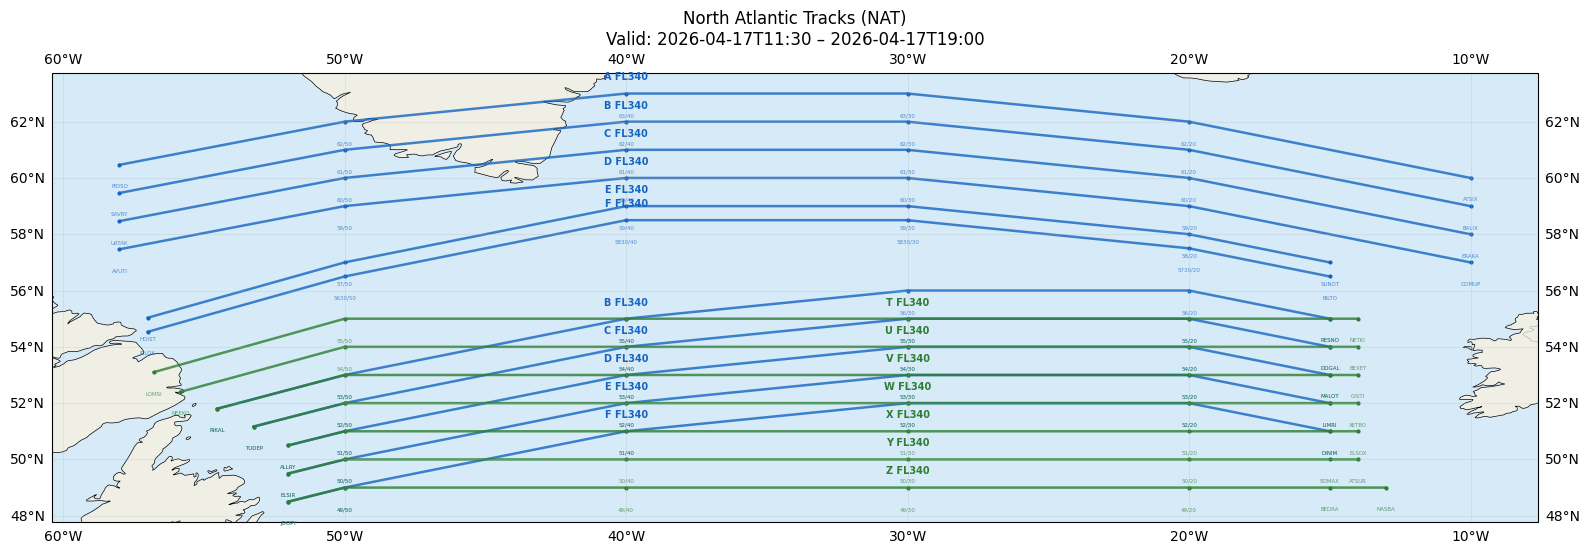

In [18]:
fpdb = FlightPlanDBClient()

try:
    nats = fpdb.fetch_nats()
    print(f"Active NAT tracks: {len(nats)}\n")
    for t in nats[:6]:
        wpts = " \u2192 ".join(w[2] for w in t.waypoints[:5])
        direction = "East" if t.east_levels else "West"
        print(f"  Track {t.ident} ({direction}): {wpts}")

    fig, ax = plot_oceanic_tracks(nats, title="North Atlantic Tracks (NAT)")
except Exception as e:
    print(f"NAT fetch failed: {e}")

try:
    pacots = fpdb.fetch_pacots()
    print(f"\nActive PACOT tracks: {len(pacots)}")
    if pacots:
        fig, ax = plot_oceanic_tracks(pacots, title="Pacific Organized Tracks (PACOT)")
except Exception as e:
    print(f"PACOT fetch failed: {e}")

## 18. Interactive Folium Map

`map_airspace()` creates an interactive Folium map with toggleable layers,
hover tooltips (name, class, altitude, schedule, severity), entry/exit
markers, and near-miss annotations.

In [19]:
m = map_airspace(
    airspaces, flight_lines, conflicts, near_misses,
)
m

## Operational Takeaways

- **Always check airspace before finalizing flight plans:** Even in seemingly remote areas, restricted and warning zones may be present. The Vandenberg example shows dense restricted airspace along the California coast.
- **Use severity levels to prioritize:** HARD conflicts (Prohibited, Restricted, SFRA) must be resolved before flight. ADVISORY conflicts (Class B/C/D, TFRs) require coordination but are usually manageable. INFO conflicts are for awareness only.
- **Schedule awareness opens corridors:** Many restricted areas (MOAs, military ranges) have published schedules. Flying outside active hours may eliminate conflicts entirely.
- **Near-miss analysis provides safety margins:** A flight line that barely clears restricted airspace is operationally risky. Use proximity buffers (2-5 km) to ensure adequate separation.
- **Vertical profiles reveal hidden conflicts:** A flight line may clear airspace horizontally but conflict vertically, or vice versa. Always check both dimensions.
- **AGL-to-MSL conversion matters in terrain:** Airspace floors referenced to the surface (AGL/SFC) must be converted to MSL using terrain data before altitude comparison is meaningful.

## Common Pitfalls

- **Relying on cached data for TFRs:** TFRs change frequently. Set short cache TTLs (1-2 hours) when checking TFRs close to flight day.
- **Ignoring "unlimited" ceilings:** Some restricted areas extend to unlimited altitude. The default 60,000 ft ceiling is conservative but may still underestimate for space-launch corridors.
- **Assuming clear airspace is permanently clear:** New TFRs can be issued on short notice (presidential travel, emergency events). Always re-check within 24 hours of flight.
- **Confusing airspace class with airspace type:** "RESTRICTED" is an airspace type, "R" is a designation. HyPlan uses `airspace_class` for Class A/B/C/D/E and `airspace_type` for SUA categories.

## Summary

### Data Sources

| Component | Purpose |
|-----------|----------|
| `NASRAirspaceSource` | US SUA, SFRA, Class B/C/D/E from FAA ArcGIS (no key). Schedule data, floor reference, 28-day cache |
| `FAATFRClient` | Active TFRs from FAA GeoServer + tfrapi (no key). Date parsing, `effective_only` filter |
| `OpenAIPClient` | Global airspace from OpenAIP (API key required). Type filter, multi-country |
| `FlightPlanDBClient` | NAT/PACOT oceanic tracks from FlightPlanDB (no key). Waypoints + flight levels |

### Data Model

| Component | Purpose |
|-----------|----------|
| `Airspace` | Dataclass: polygon + vertical limits + `floor_reference` (MSL/SFC) + `schedule` + `ceiling_unlimited` |
| `AirspaceConflict` | Conflict result: `entry_point`, `exit_point`, `distance_to_boundary_m`, `severity` |
| `OceanicTrack` | NAT/PACOT track: waypoints, flight levels, validity window, geometry |

### Analysis Functions

| Function | Purpose |
|----------|----------|
| `check_airspace_conflicts()` | Conflict detection with entry/exit point extraction |
| `check_airspace_proximity()` | Near-miss proximity warnings with configurable buffer |
| `fetch_and_check()` | One-call: FAA for US (SUA + SFRA + Class B/C/D + TFRs), OpenAIP for international |
| `classify_severity()` | Maps type to HARD (Prohibited, Restricted, SFRA) / ADVISORY (B, C, D, TFR) / INFO (E, FIR) |
| `filter_by_schedule()` | Filter MOA/restricted areas by active schedule (time + day) |
| `convert_agl_floors()` | Convert SFC floors to MSL using DEM terrain data |
| `summarize_airspaces()` | Formatted text table of airspace properties |

### Visualization

| Function | Purpose |
|----------|----------|
| `plot_airspace_map()` | Cartopy map: polygons, conflicts, entry/exit markers, near-miss halos, TFR/SFRA hatching |
| `plot_vertical_profile()` | Altitude cross-section with airspace bands, terrain, entry/exit lines |
| `plot_conflict_matrix()` | Flight line vs. airspace conflict grid (red/orange/gray) |
| `plot_oceanic_tracks()` | NAT/PACOT track map with waypoints and flight levels |
| `map_airspace()` | Interactive Folium map with hover tooltips, labels, and layer toggles |

### Helpers

| Function | Purpose |
|----------|----------|
| `FlightLine.from_endpoints()` | Create a flight line from two lat/lon pairs |
| `FlightLine.start_length_azimuth()` | Create from start point + length + heading |
| `FlightLine.center_length_azimuth()` | Create from center point + length + heading |